In [13]:
from google.colab import drive

drive.mount('/content/drive/')

Mounted at /content/drive/


In [16]:
import zipfile

zip_path = '/content/drive/MyDrive/오즈코딩/13해커톤/open.zip'
extract_path = '/content/chest_xray'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print('압축 해제 완료!')

압축 해제 완료!


In [17]:
import os
extract_path = '/content/chest_xray'

print(os.listdir(extract_path))

['sample_submission.csv', 'train.csv', 'test', 'train', 'test.csv']


In [18]:
import pandas as pd

train_csv = '/content/chest_xray/train.csv'
test_csv = '/content/chest_xray/test.csv'

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

print('===== train.csv =====')
print(train_df.head())
print('\n컬럼:')
print(train_df.columns.tolist())
print('\n크기:', train_df.shape)

print('\n===== test.csv =====')
print(test_df.head())
print('\n컬럼:')
print(test_df.columns.tolist())
print('\n크기:', test_df.shape)

===== train.csv =====
        file_name  label
0  train_0001.png      0
1  train_0002.png      0
2  train_0003.png      0
3  train_0004.png      0
4  train_0005.png      0

컬럼:
['file_name', 'label']

크기: (5216, 2)

===== test.csv =====
       file_name
0  test_0001.png
1  test_0002.png
2  test_0003.png
3  test_0004.png
4  test_0005.png

컬럼:
['file_name']

크기: (624, 1)


In [19]:
train_path = '/content/chest_xray/train'
test_path = '/content/chest_xray/test'

print('===== train 폴더 =====')
print(os.listdir(train_path)[:10])

print('\n===== test 폴더 =====')
print(os.listdir(test_path)[:10])

===== train 폴더 =====
['train_3397.png', 'train_2078.png', 'train_4927.png', 'train_3419.png', 'train_3842.png', 'train_3886.png', 'train_4542.png', 'train_4780.png', 'train_3152.png', 'train_4391.png']

===== test 폴더 =====
['test_0040.png', 'test_0594.png', 'test_0050.png', 'test_0222.png', 'test_0165.png', 'test_0035.png', 'test_0494.png', 'test_0094.png', 'test_0057.png', 'test_0258.png']


In [20]:
import pandas as pd

train_df = pd.read_csv('/content/chest_xray/train.csv')

print(train_df['label'].value_counts())
print()
print(train_df['label'].value_counts(normalize=True))

label
1    3875
0    1341
Name: count, dtype: int64

label
1    0.742906
0    0.257094
Name: proportion, dtype: float64


In [21]:
print(train_df.groupby('label').size())

label
0    1341
1    3875
dtype: int64


In [26]:
from PIL import Image
import os

train_path = '/content/chest_xray/train'

sizes = []

for file_name in os.listdir(train_path):
    file_path = os.path.join(train_path, file_name)
    with Image.open(file_path) as img:
        sizes.append(img.size)

from collections import Counter

print(Counter(sizes).most_common())

[((224, 224), 5216)]


In [27]:
sample_file = os.path.join(train_path, train_df.iloc[0]['file_name'])

with Image.open(sample_file) as img:
    print('이미지 크기:', img.size)
    print('이미지 모드:', img.mode)

이미지 크기: (224, 224)
이미지 모드: L


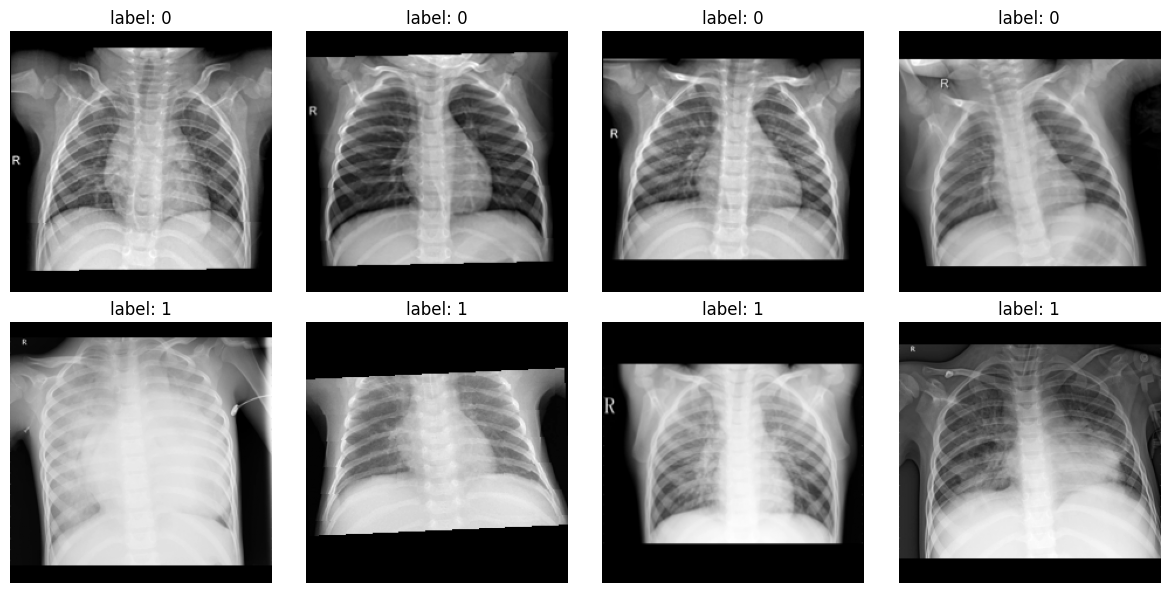

In [23]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for label in [0, 1]:
    samples = train_df[train_df['label'] == label].sample(4, random_state=42)

    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(train_path, row['file_name'])
        img = Image.open(img_path)

        ax = axes[label, i]
        ax.imshow(img, cmap='gray')
        ax.set_title(f'label: {label}')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [24]:
train_df.isnull().sum()

,0
file_name,0
label,0


In [25]:
test_df.isnull().sum()

,0
file_name,0
